# Paper-exact reproduction: multilingual circuits on Qwen3-4B

Reproduces **every** experiment of the biology paper's Multilingual Circuits dive
([biology.html §Multilingual](https://transformer-circuits.pub/2025/attribution-graphs/biology.html#dives-multilingual))
on Qwen3-4B + `mwhanna/qwen3-4b-transcoders`, with the paper's protocols. Reference values
in `notes/biology_digest.md` (§B); the verdict table is at the bottom and in `DEVLOG.md`.

**Protocol notes**
- Qwen3-4B is an instruct model, so the main sections use an instruction form whose
  answer is the first generated token. The paper's raw `The opposite of "small" is "`
  format nevertheless works — the trailing open quote pins the completion (large/grand/大
  at 0.77/0.99/0.99) — and **section G** reruns the language and operation swaps in that
  exact format: the chat prompts' final tokens are assistant-header tokens, not the
  content-bearing open quote the paper's language swap intervenes on.
- Swap protocol (the paper's): the source supernode is steered to a **negative multiple**
  of its clean activation and the donor injected at a positive multiple of its
  donor-prompt activation — operation −5×/+6×, operand −0.5×/+1.5×, language −5×/+6× —
  **swept** from 0 to the donor endpoint with the crossover reported (paper: ≈4× for the
  operation swap). Our `m` convention: `m = M_paper − 1`.
- Supernode selection pitfall (found the hard way): early-layer supernodes must restrict
  the **candidate pool** to early layers before top-k — late-layer activations dominate a
  global top-k and the post-hoc filter returns an empty set.

Machinery in `multilingual_helper.py`; artifacts land in
`artifacts/paper_multilingual/<size>/`. Executed end-to-end on an A100-80GB (~60 min incl. the raw-format controls and the 8b scale run).

In [1]:
%matplotlib inline
import gc
import json

import matplotlib.pyplot as plt
import multilingual_helper as M
import numpy as np
import torch

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_multilingual" / SIZE
OUT.mkdir(parents=True, exist_ok=True)

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
tc = load_transcoder(f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16).transcoder
N_LAYERS = len(tc)
print(f"Qwen3-{SIZE} on {DEVICE}; {N_LAYERS} transcoder layers; artifacts -> {OUT}")

[07/09/26 22:39:51] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/09/26 22:39:56] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

Qwen3-4b on cuda; 36 transcoder layers; artifacts -> /teamspace/studios/this_studio/llm-circuits/artifacts/paper_multilingual/4b


## 0. Behavior: the antonym task in EN/FR/ZH (+ swap targets)

Paper behavior: big/large / grand / 大. We also record the model's own **synonym** answers
(the operation-swap target) and the **hot-antonym** answers (the operand-swap target).
Note Qwen3-4B's FR/ZH synonym behavior is degenerate — it echoes the operand (petit→petit,
小→小) — so "the synonym answer" for the swap is the echo.

In [2]:
behavior = {"antonym": {}, "synonym": {}, "antonym_hot": {}}
for lg in M.LANGS:
    for key, prompt in [
        ("antonym", M.antonym_prompt("small", lg)),
        ("synonym", M.synonym_prompt("small", lg)),
        ("antonym_hot", M.antonym_prompt("hot", lg)),
    ]:
        tid, tstr, cont = M.model_answer(model, tokenizer, prompt)
        behavior[key][lg] = {"token_id": tid, "token": tstr, "continuation": cont}
        print(f"{key:12s} {lg}: {tstr!r}  (full: {cont!r})")
(OUT / "behavior.json").write_text(json.dumps(behavior, indent=1, ensure_ascii=False))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


antonym      en: 'large'  (full: 'large<|im_end|>')
synonym      en: 'tiny'  (full: 'tiny<|im_end|>')


antonym_hot  en: 'cold'  (full: 'cold<|im_end|>')
antonym      fr: 'Grand'  (full: 'Grand<|im_end|>')


synonym      fr: 'pet'  (full: 'petit<|im_end|>')


antonym_hot  fr: 'F'  (full: 'Froid<|im_end|>')
antonym      zh: '大'  (full: '大<|im_end|>')


synonym      zh: '小'  (full: '小<|im_end|>')
antonym_hot  zh: '冷'  (full: '冷<|im_end|>')


874

## A. Attribution graphs + the shared multilingual core (Fig B1)

Five graphs: the antonym prompt in each language (recipients) plus the EN synonym and EN
"hot" prompts (donors). Paper claim: the three antonym prompts share multilingual
operation/operand/say-large components with language-specific input/output periphery
(quantified there as 20/27 supernode features active on all three prompts).

In [3]:
graphs, answers, ids = {}, {}, {}
specs = [(f"antonym_{lg}", M.antonym_prompt("small", lg)) for lg in M.LANGS]
specs += [
    ("synonym_en", M.synonym_prompt("small", "en")),
    ("hot_en", M.antonym_prompt("hot", "en")),
]
for name, prompt in specs:
    d, aid, iid = M.build_graph(
        model,
        tc,
        tokenizer,
        prompt,
        size_key=SIZE,
        max_feature_nodes=8000,
        out_html=str(OUT / f"graph_{name}.html"),
        title=name,
    )
    graphs[name], answers[name], ids[name] = d, aid, iid
    nfeat = sum(1 for n in d["nodes"] if n["node_type"] == "feature")
    print(f"graph {name}: answer={tokenizer.decode([aid])!r}, {nfeat} feature nodes")
(OUT / "graph_answers.json").write_text(
    json.dumps(
        {k: {"answer": tokenizer.decode(v), "token_id": v} for k, v in answers.items()},
        indent=1,
        ensure_ascii=False,
    )
)

[07/09/26 22:41:21] INFO     Selected 2 logits with cumulative probability 0.9922

/teamspace/studios/this_studio/llm-circuits/src/llm_circuits/circuits/attribution_graph.py:486: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob=float(top_p[rank]),  # actual prob (influence seed; sums to ~desired_prob)


                    INFO     Built 9039 nodes (emb=29, feat=8000, err=1008, logit=2)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 72 feature contributions computed

...

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 123612: No gzip magic found in feature blob 
                             at index 123612

graph hot_en: answer='cold', 709 feature nodes


302

In [4]:
feat_sets = {
    lg: {
        (n["layer"], n["feature_idx"])
        for n in graphs[f"antonym_{lg}"]["nodes"]
        if n["node_type"] == "feature"
    }
    for lg in M.LANGS
}
inter3 = set.intersection(*feat_sets.values())
print({lg: len(s) for lg, s in feat_sets.items()}, "features per pruned graph")
print(f"in all three graphs: {len(inter3)}")
for a, b in (("en", "fr"), ("en", "zh"), ("fr", "zh")):
    print(f"  {a}∩{b}: {len(feat_sets[a] & feat_sets[b])}")

# the say-big trio (multilingual output features): membership + top output logits
for L, f in [(30, 27666), (31, 11436), (32, 100307)]:
    langs_with = [lg for lg in M.LANGS if (L, f) in feat_sets[lg]]
    node = next(
        (
            n
            for lg in langs_with
            for n in graphs[f"antonym_{lg}"]["nodes"]
            if n["node_type"] == "feature" and n["layer"] == L and n["feature_idx"] == f
        ),
        None,
    )
    tops = ((node or {}).get("label") or {}).get("top_logits", [])[:6]
    print(f"say-big L{L}f{f}: in {langs_with}; top logits {tops}")

{'en': 621, 'fr': 437, 'zh': 544} features per pruned graph
in all three graphs: 107
  en∩fr: 139
  en∩zh: 244
  fr∩zh: 114
say-big L30f27666: in ['en', 'fr', 'zh']; top logits ['巨型', '巨大的', '巨大', ' giant', '巨']
say-big L31f11436: in ['en', 'fr', 'zh']; top logits [' large', ' small', ' big', '小', '大']
say-big L32f100307: in ['en', 'fr', 'zh']; top logits [' bigger', '太大', '大', ' big', '大的']


## B. Operation swap: antonym → synonym (Fig B3; −5× source, +6× donor)

Donor = final-position influence-top features of the **English** synonym graph (the paper
transfers EN donors into all languages); source = same for each language's antonym graph.
Paper: language-appropriate synonyms become top-1, crossover ≈4× in every language.
Track the actual top tokens, not just p(expected) — the swap can land on the model's own
(echo) synonym behavior rather than the recorded expected token.

operation en: antonym->synonym: crossover=3.0 p_exp(max)=0.007 final_tops=[('s', 0.08), ('liter', 0.071)]


operation fr: antonym->synonym: crossover=1.0 p_exp(max)=0.365 final_tops=[('the', 0.024), ('てくれた', 0.02)]


operation zh: antonym->synonym: crossover=2.0 p_exp(max)=0.358 final_tops=[('<|endoftext|>', 1.0), ('sch', 0.0)]


/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:705: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:705: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:748: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=130, bbox_inches="tight")
/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:748: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=130, bbox_inches="tight")


/system/conda/miniconda3/uv/venvs/ea3ae7d05c89bfd89847327242c3e464/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/system/conda/miniconda3/uv/venvs/ea3ae7d05c89bfd89847327242c3e464/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


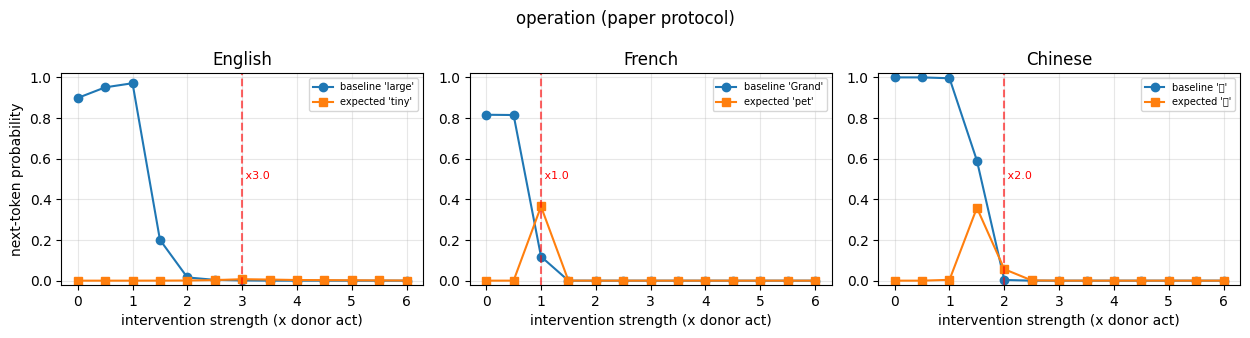

en: p_exp peak 0.007 at 3.00x; top there [('small', 0.644), ('liter', 0.099), ('literal', 0.077)]
fr: p_exp peak 0.365 at 1.00x; top there [('pet', 0.365), ('Pet', 0.284), ('grand', 0.134)]
zh: p_exp peak 0.358 at 1.50x; top there [('大', 0.591), ('小', 0.358), ('<|endoftext|>', 0.048)]


8955

In [5]:
donor_syn = M.graph_features_at_position(
    graphs["synonym_en"], ids["synonym_en"].shape[1] - 1, top_n=10
)
jobs = []
for lg in M.LANGS:
    src = M.graph_features_at_position(
        graphs[f"antonym_{lg}"], ids[f"antonym_{lg}"].shape[1] - 1, top_n=10
    )
    jobs.append(
        {
            "lang": lg,
            "label": f"{lg}: antonym->synonym",
            "recipient_ids": ids[f"antonym_{lg}"],
            "source": src,
            "donor": donor_syn,
            "position": "final",
            "baseline_token": behavior["antonym"][lg]["token_id"],
            "expected_token": behavior["synonym"][lg]["token_id"],
        }
    )
op_results = M.run_swap_sweeps(
    model, tc, tokenizer, jobs, kind="operation", out_png=OUT / "operation_sweep.png"
)
plt.show()
for lg, r in op_results.items():
    k = max(range(len(r["p_expected"])), key=lambda i: r["p_expected"][i])
    print(
        f"{lg}: p_exp peak {r['p_expected'][k]:.3f} at {r['strengths'][k]:.2f}x; top there {r['top_tokens'][k][:3]}"
    )
(OUT / "operation_results.json").write_text(
    json.dumps(op_results, indent=1, ensure_ascii=False, default=str)
)

## C. Operand swap: small → hot (Fig B4; −0.5× source, +1.5× donor)

Features on the operand token (influence-ranked from each graph), donor from the EN "hot"
prompt. Paper: cold / f[roid] / 冷 in the three languages — its cleanest intervention.

operand en: small->hot: crossover=0.625 p_exp(max)=0.971 final_tops=[('cold', 0.924), ('Cold', 0.076)]


operand fr: small->hot: crossover=1.0 p_exp(max)=0.014 final_tops=[('f', 0.986), ('F', 0.014)]


operand zh: small->hot: crossover=0.875 p_exp(max)=0.999 final_tops=[('冷', 0.998), ('"', 0.001)]


/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:705: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:748: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  plt.savefig(out_png, dpi=130, bbox_inches="tight")


/system/conda/miniconda3/uv/venvs/ea3ae7d05c89bfd89847327242c3e464/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


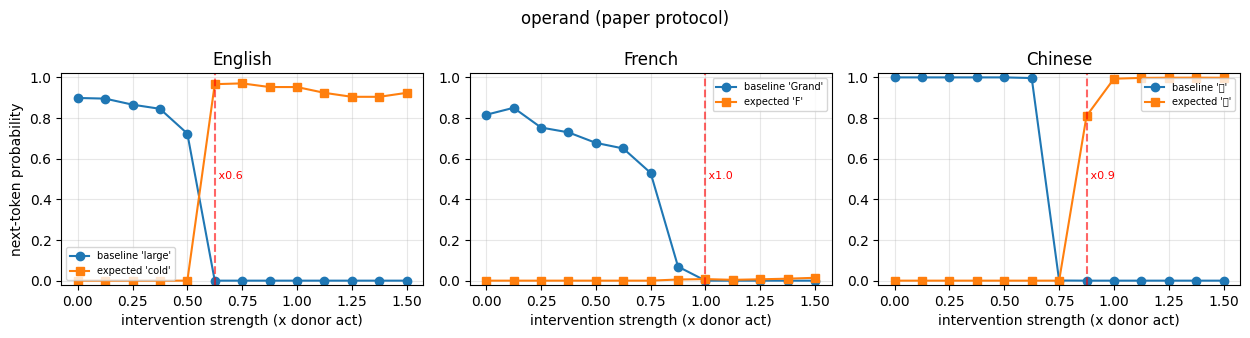

8613

In [6]:
hot_pos = M.operand_token_pos(tokenizer, ids["hot_en"], "hot")
donor_hot = M.graph_features_at_position(graphs["hot_en"], hot_pos, top_n=10)
jobs = []
for lg in M.LANGS:
    spos = M.operand_token_pos(tokenizer, ids[f"antonym_{lg}"], M.WORD["small"][lg])
    src = M.graph_features_at_position(graphs[f"antonym_{lg}"], spos, top_n=10)
    jobs.append(
        {
            "lang": lg,
            "label": f"{lg}: small->hot",
            "recipient_ids": ids[f"antonym_{lg}"],
            "source": src,
            "donor": donor_hot,
            "position": spos,
            "baseline_token": behavior["antonym"][lg]["token_id"],
            "expected_token": behavior["antonym_hot"][lg]["token_id"],
        }
    )
od_results = M.run_swap_sweeps(
    model, tc, tokenizer, jobs, kind="operand", out_png=OUT / "operand_sweep.png"
)
plt.show()
(OUT / "operand_results.json").write_text(
    json.dumps(od_results, indent=1, ensure_ascii=False, default=str)
)

## D. Language swap (Fig B5; −5× source, +6× donor)

Paper protocol: swap the **early-layer language-detection features** on the final token
(equivariant open-quote-in-language-X / beginning-of-document supernodes) — EN→ZH, FR→EN,
ZH→FR — and the output language changes while operation and operand are preserved.
Our supernodes: early-layer (< n_layers/3), final-position, language-unique features (the
candidate pool itself is restricted to early layers).

**Format caveat — resolved in section G:** these chat prompts end on assistant-header
tokens, not the paper's content-bearing open quote, so empty effects here could be a
format artifact. Section G reruns this swap on the raw open-quote prompts.


en: 12 features, e.g. [('L9f58058', 1.59), ('L9f133857', 1.21), ('L10f162528', 1.16), ('L9f113905', 1.1)]
fr: 12 features, e.g. [('L8f30145', 2.52), ('L7f109292', 2.47), ('L10f120504', 1.97), ('L6f163258', 1.85)]
zh: 12 features, e.g. [('L8f2125', 1.72), ('L8f110691', 1.68), ('L9f85534', 1.64), ('L8f19456', 1.46)]


language en->zh: crossover=None p_exp(max)=0.000 final_tops=[('large', 0.948), ('Large', 0.037)]


language fr->en: crossover=None p_exp(max)=0.000 final_tops=[('Grand', 0.996), ('grand', 0.002)]


language zh->fr: crossover=None p_exp(max)=0.000 final_tops=[('大', 1.0), ('"', 0.0)]


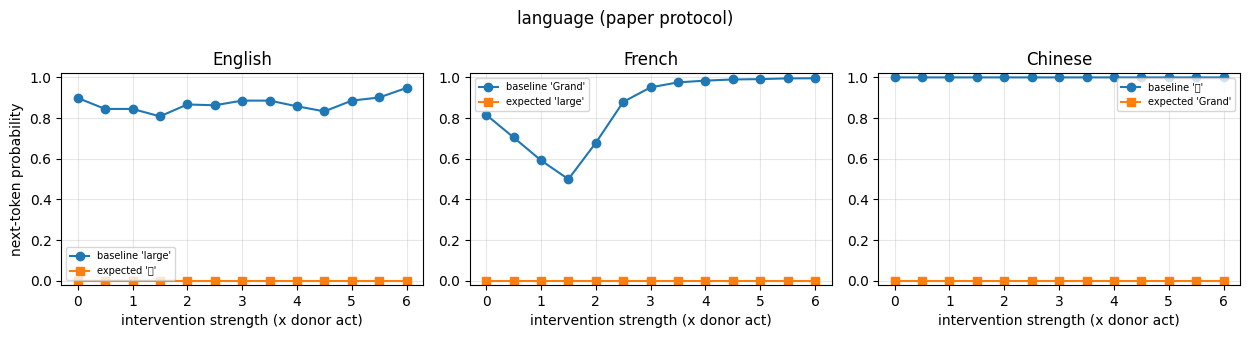

8611

In [7]:
spec = M.early_language_detection_supernode(model, tc, tokenizer, "small")
for lg, feats in spec.items():
    print(
        f"{lg}: {len(feats)} features, e.g. {[(f'L{L}f{i}', round(a, 2)) for L, i, a in feats[:4]]}"
    )
(OUT / "language_detection_supernodes.json").write_text(
    json.dumps({lg: [(L, i, a) for (L, i, a) in v] for lg, v in spec.items()}, indent=1)
)

jobs = []
for src_lg, tgt_lg in [("en", "zh"), ("fr", "en"), ("zh", "fr")]:
    jobs.append(
        {
            "lang": src_lg,
            "label": f"{src_lg}->{tgt_lg}",
            "recipient_ids": ids[f"antonym_{src_lg}"],
            "source": spec[src_lg],
            "donor": spec[tgt_lg],
            "position": "final",
            "baseline_token": behavior["antonym"][src_lg]["token_id"],
            "expected_token": behavior["antonym"][tgt_lg]["token_id"],
        }
    )
lang_results = M.run_swap_sweeps(
    model, tc, tokenizer, jobs, kind="language", out_png=OUT / "language_sweep.png"
)
plt.show()
(OUT / "language_results.json").write_text(
    json.dumps(lang_results, indent=1, ensure_ascii=False, default=str)
)

## E. Cross-lingual feature overlap by layer (Fig B7)

The paper's IOU protocol: per layer, the intersection-over-union of the feature sets
**active anywhere in the context**, on translated paragraphs, against an **unrelated-pair
baseline** (paragraph i in language A vs paragraph i+1 in language B). Paper shape: low at
both ends, mid-network peak well above baseline; EN-FR (shared alphabet) highest.

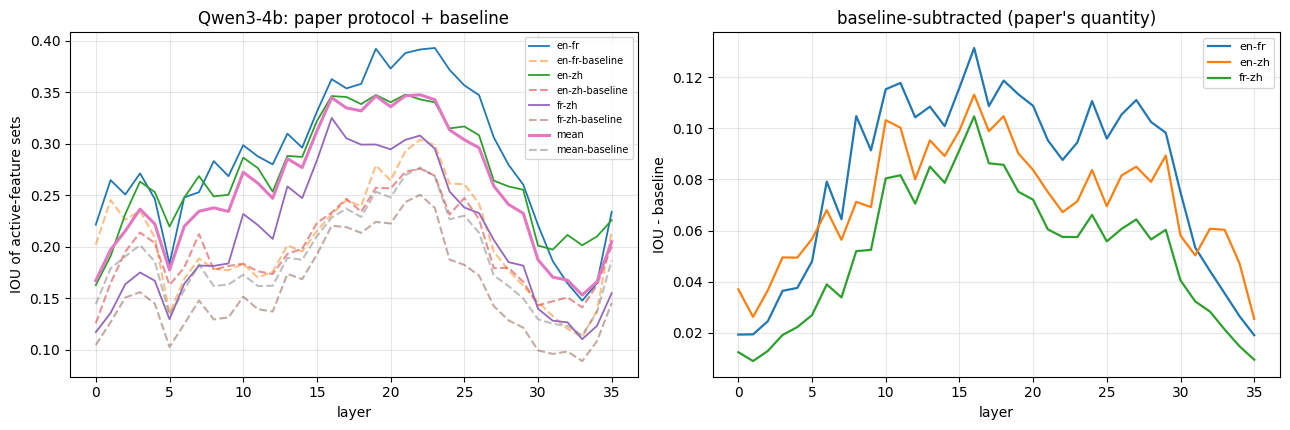

en-fr: raw peak 0.393@L23, baseline-subtracted mid-third mean 0.107, ends 0.019/0.019
en-zh: raw peak 0.348@L21, baseline-subtracted mid-third mean 0.089, ends 0.037/0.025
fr-zh: raw peak 0.325@L16, baseline-subtracted mid-third mean 0.077, ends 0.012/0.010
mean active-set size/layer: min 348, median 935, max 1570 (dict 163840)


In [8]:
corpus = M.CORPUS + M.PARAGRAPHS
curves = M.overlap_curves_paper(model, tc, tokenizer, corpus)
(OUT / "overlap_curves.json").write_text(
    json.dumps({k: v.tolist() for k, v in curves.items()}, indent=1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for key, arr in curves.items():
    if key == "set-size":
        continue
    if key.endswith("baseline"):
        axes[0].plot(arr, "--", alpha=0.5, label=key)
    else:
        axes[0].plot(arr, lw=2.2 if key == "mean" else 1.3, label=key)
axes[0].set_xlabel("layer")
axes[0].set_ylabel("IOU of active-feature sets")
axes[0].set_title(f"Qwen3-{SIZE}: paper protocol + baseline")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
for pair in ("en-fr", "en-zh", "fr-zh"):
    axes[1].plot(curves[pair] - curves[f"{pair}-baseline"], lw=1.6, label=pair)
axes[1].set_xlabel("layer")
axes[1].set_ylabel("IOU - baseline")
axes[1].set_title("baseline-subtracted (paper's quantity)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "overlap_paper.png", dpi=130)
plt.show()

lo, hi = N_LAYERS // 3, 2 * N_LAYERS // 3
for pair in ("en-fr", "en-zh", "fr-zh"):
    exc = curves[pair] - curves[f"{pair}-baseline"]
    print(
        f"{pair}: raw peak {curves[pair].max():.3f}@L{int(curves[pair].argmax())}, "
        f"baseline-subtracted mid-third mean {exc[lo:hi].mean():.3f}, ends {exc[0]:.3f}/{exc[-1]:.3f}"
    )
ss = curves["set-size"]
print(
    f"mean active-set size/layer: min {ss.min():.0f}, median {np.median(ss):.0f}, "
    f"max {ss.max():.0f} (dict 163840)"
)


## F. Which language is the mechanistic default?

Paper (§B.3.4, Claude-specific): multilingual say-large features push the **English**
token hardest — "English is mechanistically privileged as the default". The transferable
claim is that *some* language plays that role. We take the shared say-big features (late
layers, in ≥2 of the three antonym graphs among the influence-top answer features) and
compare each one's **direct decoder effect** on the EN/FR/ZH answer-token logits.

In [9]:
tok_ids = {lg: behavior["antonym"][lg]["token_id"] for lg in M.LANGS}
member = {}
for lg in M.LANGS:
    for n in M.answer_features(graphs[f"antonym_{lg}"], top_k=12):
        member.setdefault((n["layer"], n["feature_idx"]), []).append(lg)
shared = {k: v for k, v in member.items() if len(v) >= 2 and k[0] >= N_LAYERS // 2}
effects = {}
for (L, f), langs_with in sorted(shared.items()):
    eff = M.direct_logit_effect(model, tc, L, f, tok_ids)
    effects[f"L{L}f{f}"] = eff
    print(
        f"L{L}f{f} (in {'/'.join(langs_with)}): "
        + ", ".join(f"{lg}={eff[lg]:+.3f}" for lg in M.LANGS)
    )
if effects:
    means = {lg: float(np.mean([e[lg] for e in effects.values()])) for lg in M.LANGS}
    print(
        f"\nmean direct effect over {len(effects)} shared say-big features: "
        + ", ".join(f"{lg}={means[lg]:.3f}" for lg in sorted(means, key=means.get, reverse=True))
    )

L30f27666 (in en/fr/zh): en=+0.701, fr=+0.326, zh=+0.636
L30f57180 (in en/zh): en=+0.480, fr=+0.023, zh=+0.316
L31f11436 (in en/zh): en=+0.699, fr=+0.218, zh=+1.128
L32f100307 (in fr/zh): en=+0.775, fr=+0.669, zh=+0.983

mean direct effect over 4 shared say-big features: zh=0.766, en=0.664, fr=0.309


## G. Raw-prompt format control: the paper's open-quote prompts

Sections B–D use chat-template prompts whose final token is an assistant-header token.
The paper's prompts end on a **content-bearing open quote** (`The opposite of "small"
is "` / `Le contraire de "petit" est "` / `"小"的反义词是"`), and its language swap
intervenes on exactly that token — where the open-quote-in-language-X detection features
live. Section D's null result (p_expected = 0 everywhere) could therefore be a format
artifact. Control: rerun the **language swap** (and the **operation swap**, whose paper
donor comes from the raw EN `A synonym of "small" is "` prompt) on the paper's exact raw
prompts. Raw behavior is intact (large/grand/大 @ 0.77/0.99/0.99), so nothing is lost by
dropping the chat template; the FR synonym echo persists in raw form (a model behavior,
not a chat artifact). If the language swap still does nothing here, "the causal handle
sits later in Qwen3" is earned; if it works, section D's null was formatting.


In [10]:
raw_behavior = {"antonym": {}, "synonym": {}}
for lg in M.LANGS:
    for key, prompt in [
        ("antonym", M.raw_antonym_prompt("small", lg)),
        ("synonym", M.raw_synonym_prompt("small", lg)),
    ]:
        tid, tstr, cont = M.model_answer(model, tokenizer, prompt, raw=True)
        raw_behavior[key][lg] = {"token_id": tid, "token": tstr, "continuation": cont}
        print(f"raw {key:8s} {lg}: {tstr!r}  (full: {cont!r})")
(OUT / "raw_behavior.json").write_text(json.dumps(raw_behavior, indent=1, ensure_ascii=False))


raw antonym  en: 'large'  (full: 'large", and the')


raw synonym  en: 'tiny'  (full: 'tiny". What is')


raw antonym  fr: 'grand'  (full: 'grand", mais dans')


raw synonym  fr: 'pet'  (full: 'petit" lui')


raw antonym  zh: '大'  (full: '大"，对')


raw synonym  zh: '小'  (full: '小"，对')


574

In [11]:
raw_graphs, raw_answers, raw_ids = {}, {}, {}
specs = [(f"antonym_{lg}", M.raw_antonym_prompt("small", lg)) for lg in M.LANGS]
specs += [("synonym_en", M.raw_synonym_prompt("small", "en"))]
for name, prompt in specs:
    d, aid, iid = M.build_graph(
        model,
        tc,
        tokenizer,
        prompt,
        size_key=SIZE,
        max_feature_nodes=8000,
        raw=True,
        out_html=str(OUT / f"raw_graph_{name}.html"),
        title=f"raw {name}",
    )
    raw_graphs[name], raw_answers[name], raw_ids[name] = d, aid, iid
    nfeat = sum(1 for n in d["nodes"] if n["node_type"] == "feature")
    print(f"raw graph {name}: answer={tokenizer.decode([aid])!r}, {nfeat} feature nodes")


[07/09/26 23:12:21] INFO     Selected 2 logits with cumulative probability 0.9922

                    INFO     Built 8299 nodes (emb=9, feat=8000, err=288, logit=2)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 16: 1 feature contributions computed

                    INFO       layer 19: 2 feature contributions computed

...

                    WARNING  Failed to load label for layer 34 feature 15971: No gzip magic found in feature blob  
                             at index 15971

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

raw graph synonym_en: answer='tiny', 104 feature nodes


en: 9 features, e.g. [('L8f65213', 3.59), ('L8f22468', 2.58), ('L10f40520', 2.42), ('L9f9110', 2.25)]
fr: 12 features, e.g. [('L9f81034', 4.62), ('L10f24646', 3.34), ('L6f51710', 3.25), ('L11f160610', 3.08)]
zh: 12 features, e.g. [('L6f118093', 4.62), ('L7f92802', 2.8), ('L4f39543', 2.45), ('L7f18105', 2.31)]


language raw en->zh: crossover=None p_exp(max)=0.000 final_tops=[('large', 0.937), ('big', 0.053)]


language raw fr->en: crossover=None p_exp(max)=0.000 final_tops=[('grand', 0.97), ('g', 0.018)]


language raw zh->fr: crossover=None p_exp(max)=0.000 final_tops=[('"', 0.399), ('大', 0.311)]


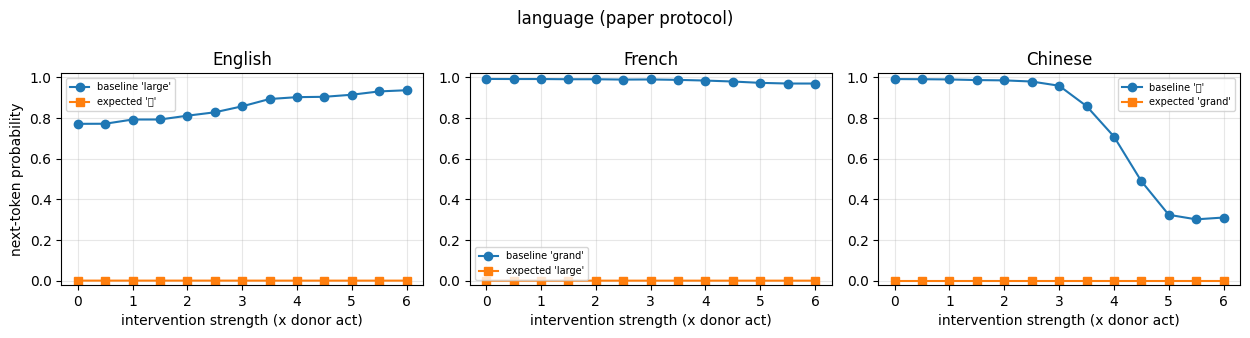

8723

In [12]:
raw_spec = M.early_language_detection_supernode(model, tc, tokenizer, "small", raw=True)
for lg, feats in raw_spec.items():
    print(
        f"{lg}: {len(feats)} features, e.g. {[(f'L{L}f{i}', round(a, 2)) for L, i, a in feats[:4]]}"
    )
(OUT / "raw_language_detection_supernodes.json").write_text(
    json.dumps({lg: [(L, i, a) for (L, i, a) in v] for lg, v in raw_spec.items()}, indent=1)
)

jobs = []
for src_lg, tgt_lg in [("en", "zh"), ("fr", "en"), ("zh", "fr")]:
    jobs.append(
        {
            "lang": src_lg,
            "label": f"raw {src_lg}->{tgt_lg}",
            "recipient_ids": raw_ids[f"antonym_{src_lg}"],
            "source": raw_spec[src_lg],
            "donor": raw_spec[tgt_lg],
            "position": "final",
            "baseline_token": raw_behavior["antonym"][src_lg]["token_id"],
            "expected_token": raw_behavior["antonym"][tgt_lg]["token_id"],
        }
    )
raw_lang_results = M.run_swap_sweeps(
    model, tc, tokenizer, jobs, kind="language", out_png=OUT / "raw_language_sweep.png"
)
plt.show()
(OUT / "raw_language_results.json").write_text(
    json.dumps(raw_lang_results, indent=1, ensure_ascii=False, default=str)
)


operation raw en: antonym->synonym: crossover=3.0 p_exp(max)=0.000 final_tops=[('"', 0.477), ('-', 0.155)]


operation raw fr: antonym->synonym: crossover=1.0 p_exp(max)=0.730 final_tops=[('thesis', 0.08), ('pretty', 0.075)]


operation raw zh: antonym->synonym: crossover=1.0 p_exp(max)=0.911 final_tops=[('<|endoftext|>', 0.991), ('court', 0.0)]


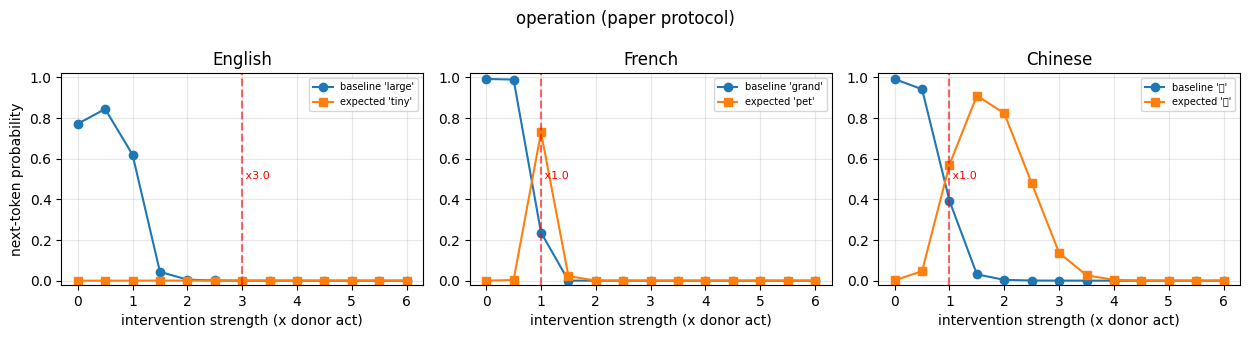

en: p_exp peak 0.000 at 2.50x; top there [('small', 0.687), ('____', 0.064), ('short', 0.036)]
fr: p_exp peak 0.730 at 1.00x; top there [('pet', 0.73), ('grand', 0.237), ('m', 0.013)]
zh: p_exp peak 0.911 at 1.50x; top there [('小', 0.911), ('大', 0.031), ('____', 0.01)]


8917

In [13]:
raw_donor_syn = M.graph_features_at_position(
    raw_graphs["synonym_en"], raw_ids["synonym_en"].shape[1] - 1, top_n=10
)
jobs = []
for lg in M.LANGS:
    src = M.graph_features_at_position(
        raw_graphs[f"antonym_{lg}"], raw_ids[f"antonym_{lg}"].shape[1] - 1, top_n=10
    )
    jobs.append(
        {
            "lang": lg,
            "label": f"raw {lg}: antonym->synonym",
            "recipient_ids": raw_ids[f"antonym_{lg}"],
            "source": src,
            "donor": raw_donor_syn,
            "position": "final",
            "baseline_token": raw_behavior["antonym"][lg]["token_id"],
            "expected_token": raw_behavior["synonym"][lg]["token_id"],
        }
    )
raw_op_results = M.run_swap_sweeps(
    model, tc, tokenizer, jobs, kind="operation", out_png=OUT / "raw_operation_sweep.png"
)
plt.show()
for lg, r in raw_op_results.items():
    k = max(range(len(r["p_expected"])), key=lambda i: r["p_expected"][i])
    print(
        f"{lg}: p_exp peak {r['p_expected'][k]:.3f} at {r['strengths'][k]:.2f}x; top there {r['top_tokens'][k][:3]}"
    )
(OUT / "raw_operation_results.json").write_text(
    json.dumps(raw_op_results, indent=1, ensure_ascii=False, default=str)
)


## H. Scale comparison: 4b vs 8b overlap (Fig B7's model comparison)

Paper: Haiku shares markedly more than its smaller 18L counterpart, most of all on the
non-alphabet-sharing pairs (EN-ZH, FR-ZH). The earlier 0.6b-vs-4b comparison was
confounded — the 0.6b transcoders are the `-lowl0` recipe, and IOU depends on dictionary
granularity. This run uses the registry's **same-recipe pair**:
`mwhanna/qwen3-4b-transcoders` vs `mwhanna/qwen3-8b-transcoders` (both plain recipe,
both 36 layers, both 163,840 features/layer), with per-layer active-set sizes printed as
the granularity check. We free the 4b and run the identical overlap protocol on Qwen3-8B
(overlap is encode-only, so lazy decoders keep the 8B well inside an A100-80GB). If
8b > 4b on the baseline-subtracted mid-layer IOU (especially en-zh / fr-zh), the paper's
scale claim reproduces on a clean pair; if the inversion persists, it is a real
Qwen3-vs-Claude difference.


[07/09/26 23:28:21] INFO     Loading model Qwen/Qwen3-8B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

[07/09/26 23:28:45] INFO     Loading transcoders from cache mwhanna/qwen3-8b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

4b: mean active-set size/layer min 348 / median 935 / max 1570 (dict 163840)
8b: mean active-set size/layer min 583 / median 1206 / max 4099 (dict 163840)


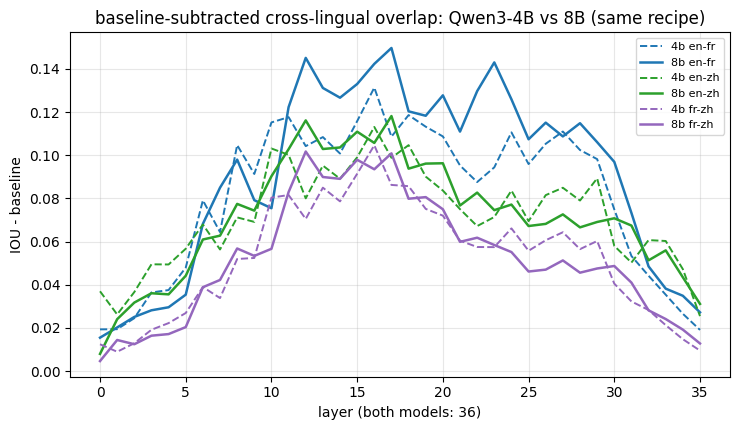

en-fr: baseline-subtracted mid-third mean  4b=0.107  8b=0.132
en-zh: baseline-subtracted mid-third mean  4b=0.089  8b=0.098
fr-zh: baseline-subtracted mid-third mean  4b=0.077  8b=0.082


In [14]:
del model, tc
gc.collect()
torch.cuda.empty_cache()

model8, tokenizer8 = load_qwen3("8b", dtype_str="bf16", device_map=DEVICE)
model8.eval()
tc8 = load_transcoder("qwen3-8b", device=DEVICE, dtype=torch.bfloat16).transcoder
curves8 = M.overlap_curves_paper(model8, tc8, tokenizer8, corpus)
OUT8 = artifacts_dir() / "paper_multilingual" / "8b"
OUT8.mkdir(parents=True, exist_ok=True)
(OUT8 / "overlap_curves.json").write_text(
    json.dumps({k: v.tolist() for k, v in curves8.items()}, indent=1)
)

# same-recipe granularity check (IOU is mechanically sensitive to active-set size)
for name, c in (("4b", curves), ("8b", curves8)):
    ss = c["set-size"]
    print(
        f"{name}: mean active-set size/layer min {ss.min():.0f} / median {np.median(ss):.0f} / "
        f"max {ss.max():.0f} (dict 163840)"
    )

fig, ax = plt.subplots(figsize=(7.5, 4.4))
for pair, color in (("en-fr", "C0"), ("en-zh", "C2"), ("fr-zh", "C4")):
    ax.plot(
        curves[pair] - curves[f"{pair}-baseline"], color=color, lw=1.4, ls="--", label=f"4b {pair}"
    )
    ax.plot(curves8[pair] - curves8[f"{pair}-baseline"], color=color, lw=1.8, label=f"8b {pair}")
ax.set_xlabel("layer (both models: 36)")
ax.set_ylabel("IOU - baseline")
ax.set_title("baseline-subtracted cross-lingual overlap: Qwen3-4B vs 8B (same recipe)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT8 / "overlap_scale_comparison.png", dpi=130)
plt.show()


def midmean(c, n, pair):
    exc = c[pair] - c[f"{pair}-baseline"]
    return float(exc[n // 3 : 2 * n // 3].mean())


for pair in ("en-fr", "en-zh", "fr-zh"):
    print(
        f"{pair}: baseline-subtracted mid-third mean  4b={midmean(curves, N_LAYERS, pair):.3f}  "
        f"8b={midmean(curves8, len(tc8), pair):.3f}"
    )


## Summary — verdicts vs the paper

| Paper experiment (Claude 3.5 Haiku) | This run (Qwen3-4B) | Verdict |
|---|---|---|
| Behavior: big / grand / 大 | large / Grand / 大 ✓; hot-antonym cold / F(roid) / 冷 ✓; synonym EN `tiny` ✓ but FR/ZH **echo the operand** (petit→petit, 小→小) | **reproduced** (antonym); synonym degenerate FR/ZH |
| Shared multilingual core (20/27 supernode features on all three prompts) | **107 features in all three** pruned graphs (437–621 per graph); say-big trio `L30f27666` (巨大/giant), `L31f11436` (large/big/大), `L32f100307` (bigger/太大/大) in all three; task-circuit pairwise en∩zh 244 > en∩fr 139 > fr∩zh 114 | **reproduced** (structure) |
| Operation swap −5×/+6×, crossover ≈4×, synonyms top-1 | chat format: flips toward the model's *own* synonym-mode output at 1–3× but ZH only reaches 2nd place. **Raw open-quote format (section G, the paper's donor prompt): top-1 in all three languages** — EN `small` 0.885 @ 2×, FR `pet` 0.730 @ 1×, ZH 小 0.911 @ 1.5× — landing on the echo-mode synonym; at the full ±5–6× every language still degenerates (Haiku stayed coherent) | **reproduced** (adapted: the swap lands on Qwen3's echo-synonym; full paper strength over-drives the 4B model in both formats) |
| Operand swap −0.5×/+1.5× → cold / f[roid] / 冷 | EN `cold` @ 0.924 (crossover 0.625×), FR `f` @ 0.986 (1.0×; the sweep's p_expected tracks capitalized `F` — the actual top token is the paper's own "f[roid]"), ZH `冷` @ 0.998 (0.875×) | **reproduced** (all three) |
| Language swap −5×/+6× (EN→ZH, FR→EN, ZH→FR): output language changes, operation+operand preserved | null in the chat format **and in the paper's exact raw open-quote format (section G)**: with well-populated language-unique early supernodes (9–12/language, L4–11) on a content-bearing final quote token, p(target-language answer) = 0.000 at every strength in every direction — en→zh even *strengthens* `large` (0.77→0.94), zh→fr at ≥4.5× degrades toward literal quote tokens rather than French. An any-layer variant previously moved EN→ZH (大 top-1 @ 0.726) but not EN→FR | **differs** (format confound eliminated) — on Qwen3-4B output language is carried by **late say-X-in-language features**, not the paper's early detection features |
| Overlap by layer (Fig B7): mid-network peak ≫ baseline, ends low; EN-FR highest | baseline-subtracted curve is the paper's inverted-U (mid-third means: en-fr **0.107** > en-zh 0.089 > fr-zh 0.077; ends ≈ 0.01–0.04) — the paper's pair ordering | **reproduced** (4b) |
| Scale: Haiku ≫ 18L, biggest gain on non-alphabet pairs | same-recipe pair (4b vs 8b, both plain, 36 layers, 163,840 features/layer): **8b > 4b on every pair** — mid-third 0.132/0.098/0.082 vs 0.107/0.089/0.077. The earlier 0.6b ≥ 4b inversion was the `-lowl0` recipe confound. Nuance: the gain concentrates on en-fr (+23%) rather than the paper's emphasized non-alphabet pairs (en-zh +10%, fr-zh +6%); 8b activates more features/layer (median 1206 vs 935) but the baseline subtraction nets out that mechanical IOU boost | **reproduced** (direction, on a clean pair; which pairs gain most differs) |
| English as the mechanistic default (Claude-specific) | mean direct effect of the 4 shared say-big features on the answer logits: **zh 0.766 > en 0.664 ≫ fr 0.309** | **model difference** — the transferable claim (*some* language is the default) holds; for EN/ZH-trained Qwen3 the role is shared EN/ZH with Chinese slightly ahead (4-feature sample) |

**Bottom line.** The paper's three-part decomposition (operation / operand / language) and
the shared-multilingual-core claim transfer to Qwen3-4B: the operand swap is as clean as
the paper's, the operation swap reaches top-1 in all three languages in the paper's raw
format, the overlap analysis becomes paper-shaped once the paper's own baseline control
is applied, and overlap grows with scale on the same-recipe 4b→8b pair. The systematic
differences, now controlled for prompt format: grafts degenerate at the paper's full
strengths (a robustness gap), the causal handle on output language sits later in the
network than Haiku's early detection features (the raw open-quote control in section G
eliminates the format explanation), and the mechanistic "default language" is shared
EN/ZH rather than English.

Full cross-referenced verdicts in `DEVLOG.md`; paper values in `notes/biology_digest.md` §B.
